All Imports


In [1]:


import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from chonkie import OpenAIEmbeddings
import time

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


Set the API Key

In [2]:


load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")


Embeddings


In [3]:


embeddings = OpenAIEmbeddings()
text = "Hello Testing the embedding"
test_vector = embeddings.embed(text)

print(f"Embedding Dimension: {len(test_vector)}")
print(f"Sample embeddings: {test_vector[:5]}")


Embedding Dimension: 1536
Sample embeddings: [ 0.00170803 -0.00760269  0.03552246 -0.02742004 -0.01048279]


Reading Files


In [8]:


with open("new_data/sample_research_paper.txt", "r") as file:
    research_paper_text = file.read()

with open("new_data/sample_code.py", "r") as file:
    code_text = file.read()

with open("new_data/sample_table.md", "r") as file:
    table_text = file.read()

with open("new_data/sample_technical_doc.txt", "r") as file:
    technical_doc_text = file.read()

print(f"Technical Doc: {len(technical_doc_text):,} characters")
print(f"Research Paper: {len(research_paper_text):,} characters")
print(f"Code Sample: {len(code_text):,} characters")
print(f"Table Sample: {len(table_text):,} characters")


Technical Doc: 7,473 characters
Research Paper: 14,482 characters
Code Sample: 12,943 characters
Table Sample: 6,159 characters


Helper functions

In [4]:
def display_chunks(chunks,max_display=3,show_metadata=True):
    """Display chunk size"""
    print(f"\n Total Lenght of chunks {len(chunks)}")
    print("*"*80)
    
    for i,chunk in enumerate(chunks[:max_display]):
        print(f"\n Chunk {i+1}: {chunk.text[:200]}....")
        if show_metadata and hasattr(chunk,'token_count'):
            if show_metadata and hasattr(chunk,'start_char'):
                print(f"Position: {chunk.start_char}-{chunk.end_char}")
        print('-'*80)
    
    if (max_display<len(chunks)):
        print(f"\n{len(chunks)-max_display} chunks left")
    

def visualize_chunk_size(chunks,title="Chunk Size Distribution"):
    token_counts=[chunk.token_count if hasattr(chunk,"token_count") else len(chunk.text) for chunk in chunks]
    print(f"Token Count:{token_counts}")
    plt.subplot(1, 2, 1)
    plt.hist(token_counts, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel('Token Count')
    plt.ylabel('Frequency')
    plt.title(f'{title}\nDistribution')
    plt.axvline(np.mean(token_counts), color='red', linestyle='--', label=f'Mean: {np.mean(token_counts):.0f}')
    plt.legend()
    
    # Box plot
    plt.subplot(1, 2, 2)
    plt.boxplot(token_counts, vert=True)
    plt.ylabel('Token Count')
    plt.title(f'{title}\nBox Plot')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nStatistics:")
    print(f"  Mean: {np.mean(token_counts):.1f}")
    print(f"  Median: {np.median(token_counts):.1f}")
    print(f"  Std Dev: {np.std(token_counts):.1f}")
    print(f"  Min: {min(token_counts)}")
    print(f"  Max: {max(token_counts)}")

def compare_chunkers(chunk,chunker_dict,sample_size=1000):
    """Compare multiple chunkers at the same time"""
    sample_text= chunk[:sample_size] if len(chunk)>sample_size else text
    result={}
    for name,chunker in chunker_dict.items():
        start_time=time.time()
        chunked_text=chunker.chunk(sample_text)
        elapsed_time=time.time()-start_time
        token_counts=[chunk.token_count if hasattr(chunk,'token_count') else len(chunk.text) for chunk in chunked_text]

        result[name]={
            "num_chunks":len(chunked_text),
            "avg_size":np.mean(token_counts),
            "standard_meridian":np.std(token_counts),
            "elapsed":elapsed_time
        }
    
    df=pd.DataFrame(result).T
    return df

print("Helper Function Loaded")


Helper Function Loaded



 Total Lenght of chunks 6
********************************************************************************

 Chunk 1: # Chonkie API Documentation

## Overview

Chonkie is a lightweight, high-performance library for chunking text in Retrieval-Augmented Generation (RAG) applications. It provides a comprehensive suite o....
--------------------------------------------------------------------------------

 Chunk 2: "]
batch_chunks = chunker.chunk_batch(texts)
```

### TokenChunker API

The TokenChunker splits text into fixed-size token chunks with configurable overlap.

**Parameters:**
- `tokenizer` (Tokenizer):....
--------------------------------------------------------------------------------

 Chunk 3:  limits.

**Parameters:**
- `tokenizer` (Tokenizer): Tokenizer instance
- `chunk_size` (int): Maximum tokens per chunk (default: 512)
- `min_sentences_per_chunk` (int): Minimum sentences per chunk (de....
--------------------------------------------------------------------------------



/var/folders/j_/jb1h_wtd21zfymdrgw0tg8500000gn/T/ipykernel_99311/2283517303.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(token_counts, vert=True)


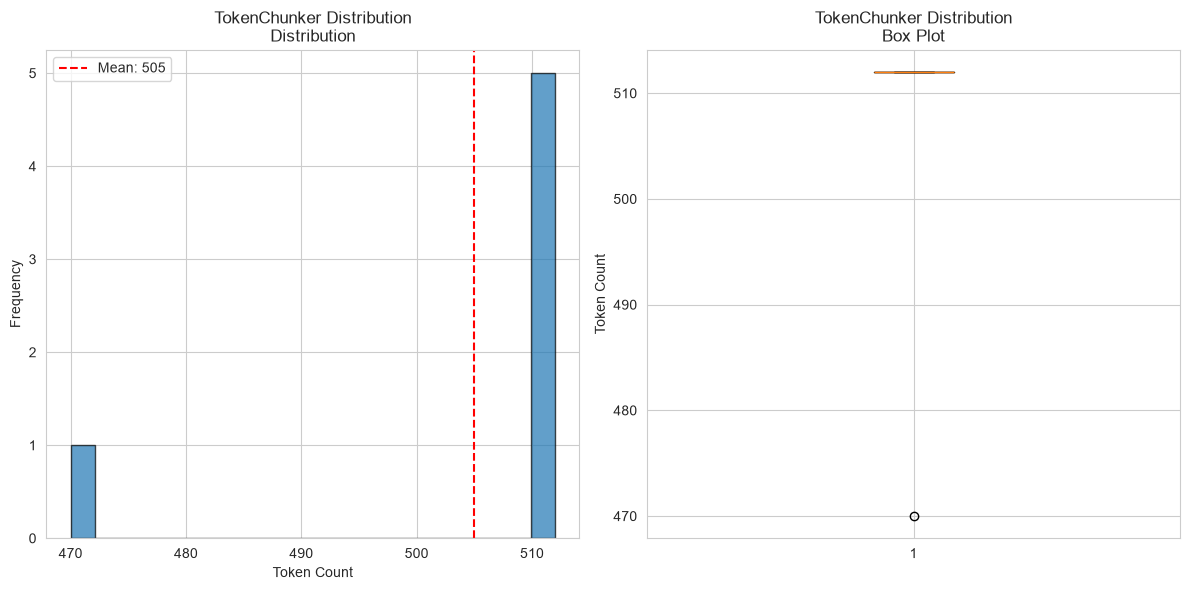


Statistics:
  Mean: 505.0
  Median: 512.0
  Std Dev: 15.7
  Min: 470
  Max: 512


In [44]:
from chonkie import TokenChunker
from tokenizers import Tokenizer

tokenizer=Tokenizer.from_pretrained('gpt2')
token_chunker=TokenChunker(
    tokenizer=tokenizer,
    chunk_size=512,
    chunk_overlap=128
)
chunks=token_chunker.chunk(technical_doc_text)
display_chunks(chunks)
visualize_chunk_size(chunks,"TokenChunker Distribution")


The Mean(505.0) chunk size is often used to estimate storage and memory requirements
Example

Suppose your document produced 1,000 chunks.

Average tokens per chunk = 505

Then

Total stored tokens ≈ 1000 × 505 = 505,000 tokens

If every token embedding is stored as a vector of 1536 dimensions (OpenAI's older embedding size) using float32:

Memory per embedding
= 1536 × 4 bytes
≈ 6144 bytes
≈ 6 KB

Then

1000 chunks
≈ 1000 × 6 KB
≈ 6 MB

Suppose your original document contains 5,050,000 tokens.

Average chunk size = 505 tokens.

Then

Estimated chunks=
505
5,050,000
	​

=10,000

Now you know you'll generate approximately 10,000 embeddings.

Then

10,000 embeddings
× 1536 dimensions
× 4 bytes
≈ 61 MB

INTERPRETATION OF THE HISTOGRAM

This histogram appears to show the distribution of token counts produced by a TokenChunker.

What it shows
Most token counts are clustered around 510–512.
    There are about 5 observations in this range.
    This indicates the chunker is consistently producing chunks very close to the target size.
There is one observation around 470 tokens.
    This is noticeably smaller than the others.
    It is likely the last chunk of a document, which often contains the remaining text after all full-sized chunks have been created.
The red dashed line marks the mean (average) token count: 505.
    The mean is lower than the main cluster because the single 470-token chunk pulls the average down.
    Without that smaller chunk, the mean would be very close to 511.
Distribution characteristics
    Center: Around 510 tokens, even though the mean is 505.
    Spread: Very small. Most values differ by only 1–2 tokens.
    Shape: Not symmetric. It consists of one tight cluster near 510 and one smaller value around 470.
    Outliers: The ~470-token chunk could be considered an outlier relative to the others, though in chunking applications this is usually expected rather than problematic.
    Consistency: High. The chunker is producing nearly uniform chunk sizes.

Practical interpretation
    For a token chunker, this is generally a good distribution because:
    Nearly all chunks are close to the desired size (~512 tokens).
    Only one chunk is shorter, which is expected if it is the final chunk of the input.
    There is no evidence of large variability or inconsistent chunk sizes.


 Total Lenght of chunks 6
********************************************************************************

 Chunk 1: Semantic Chunking Strategies for Retrieval-Augmented Generation Systems

Abstract

Retrieval-Augmented Generation (RAG) systems have emerged as a powerful paradigm for enhancing large language models ....
--------------------------------------------------------------------------------

 Chunk 2: Neural approaches employ fine-tuned models to detect discourse-level shifts, while late chunking techniques defer segmentation until after contextualized embedding generation.

This paper makes the fo....
--------------------------------------------------------------------------------

 Chunk 3: However, these approaches have not been systematically compared across diverse document types and retrieval scenarios.

3. Methodology

3.1 Chunking Algorithms

We evaluate nine distinct chunking stra....
--------------------------------------------------------------------------------



/var/folders/j_/jb1h_wtd21zfymdrgw0tg8500000gn/T/ipykernel_99311/2283517303.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(token_counts, vert=True)


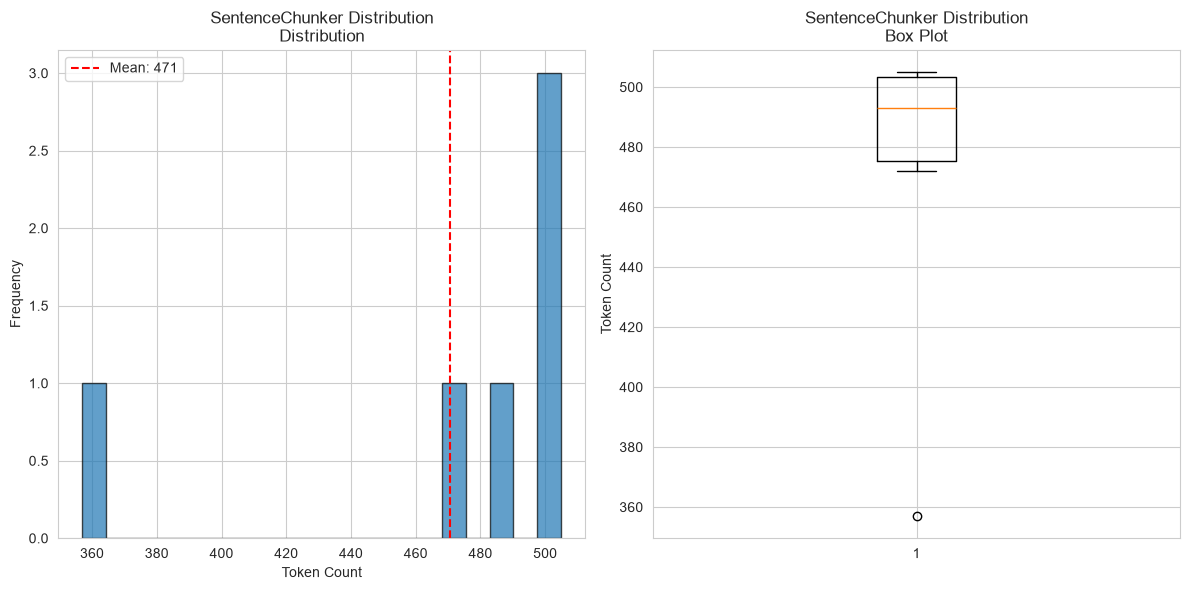


Statistics:
  Mean: 470.7
  Median: 493.0
  Std Dev: 52.2
  Min: 357
  Max: 505


In [48]:
from tokenizers import Tokenizer
from chonkie import SentenceChunker

tokenizer=Tokenizer.from_pretrained('gpt2')
sentence_chunker=SentenceChunker(
    tokenizer=tokenizer,
    chunk_size=512,
    min_sentences_per_chunk=3
)

sentence_chunks=sentence_chunker.chunk(research_paper_text)
display_chunks(sentence_chunks)
visualize_chunk_size(sentence_chunks,'SentenceChunker Distribution')

In [46]:
comparision_text=research_paper_text[:5000]
token_chunker_text=token_chunker.chunk(comparision_text)
sentence_chunker_text=sentence_chunker.chunk(comparision_text)

print(f"Comparision on same text")
print(f"\n Token Chunker: {len(token_chunker_text)} chunks")
print(f"\n Sentence Chunker: {len(sentence_chunker_text)} chunks")

print(f"\n Token Chunker first chunk")
print(f"{token_chunker_text[0].text[:600]}")
print(f"\n Sentence Chunker first chunk")
print(f"{sentence_chunker_text[0].text[:600]}")

Comparision on same text

 Token Chunker: 2 chunks

 Sentence Chunker: 2 chunks

 Token Chunker first chunk
Semantic Chunking Strategies for Retrieval-Augmented Generation Systems

Abstract

Retrieval-Augmented Generation (RAG) systems have emerged as a powerful paradigm for enhancing large language models with external knowledge. A critical component of RAG systems is text chunking - the process of segmenting documents into manageable units for embedding and retrieval. This paper presents a comprehensive analysis of semantic chunking strategies, comparing traditional fixed-size approaches with modern embedding-based methods. We evaluate nine distinct chunking algorithms across multiple dimensions i

 Sentence Chunker first chunk
Semantic Chunking Strategies for Retrieval-Augmented Generation Systems

Abstract

Retrieval-Augmented Generation (RAG) systems have emerged as a powerful paradigm for enhancing large language models with external knowledge. A critical component of RAG systems


 Total Lenght of chunks 6
********************************************************************************

 Chunk 1: # Chonkie API Documentation

## Overview

Chonkie is a lightweight, high-performance library for chunking text in Retrieval-Augmented Generation (RAG) applications. It provides a comprehensive suite o....
--------------------------------------------------------------------------------

 Chunk 2: "]
batch_chunks = chunker.chunk_batch(texts)
```

### TokenChunker API

The TokenChunker splits text into fixed-size token chunks with configurable overlap.

**Parameters:**
- `tokenizer` (Tokenizer):....
--------------------------------------------------------------------------------

 Chunk 3:  limits.

**Parameters:**
- `tokenizer` (Tokenizer): Tokenizer instance
- `chunk_size` (int): Maximum tokens per chunk (default: 512)
- `min_sentences_per_chunk` (int): Minimum sentences per chunk (de....
--------------------------------------------------------------------------------



/var/folders/j_/jb1h_wtd21zfymdrgw0tg8500000gn/T/ipykernel_99311/2283517303.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(token_counts, vert=True)


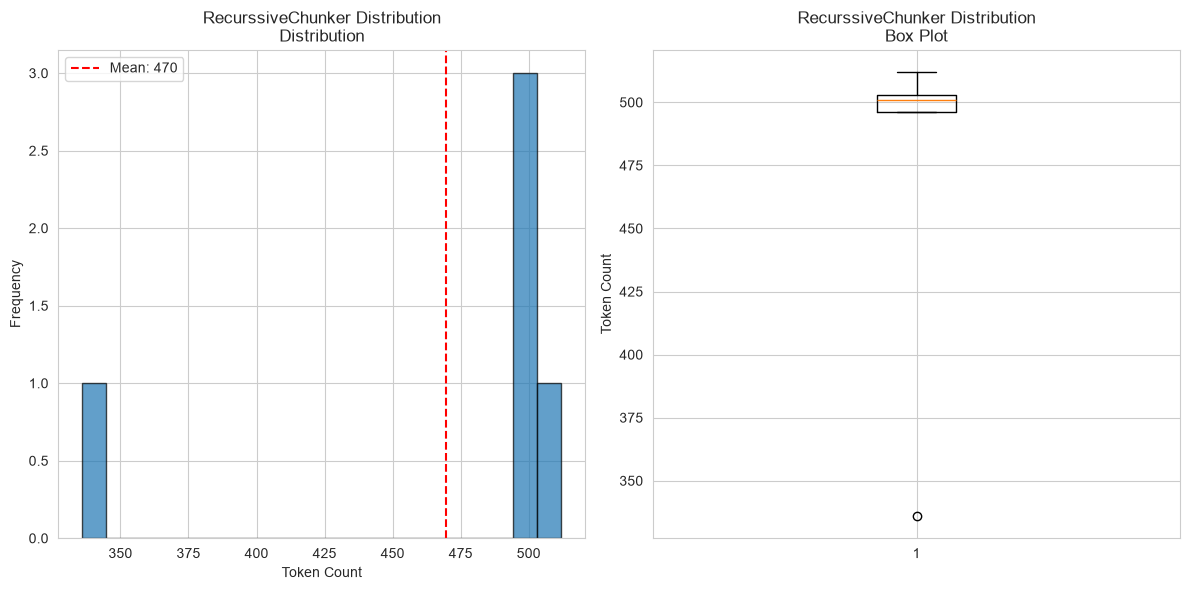


Statistics:
  Mean: 469.6
  Median: 501.0
  Std Dev: 67.0
  Min: 336
  Max: 512


In [50]:
from tokenizers import Tokenizer
from chonkie import RecursiveChunker

tokenizer=Tokenizer.from_pretrained('gpt2')
recurssive_chunker=RecursiveChunker(
    chunk_size=512,
    tokenizer=tokenizer
)
recurssive_chunk=recurssive_chunker.chunk(technical_doc_text)
display_chunks(chunks)
visualize_chunk_size(recurssive_chunk,"RecurssiveChunker Distribution")

Specialized Chunkers

In [51]:
from chonkie import TableChunker
from tokenizers import Tokenizer

tokenizer=Tokenizer.from_pretrained('gpt2')
table_chunker=TableChunker(
    tokenizer=tokenizer,
    chunk_size=512
)
table_chunks=table_chunker.chunk(table_text)
print(f"Table split into {len(table_chunks)} chunks")
print(f"\nInitial CHunks: \n")
print(table_chunks[0].text)


Table split into 5 chunks

Initial CHunks: 

# Chonkie Chunkers Comparison Table

## Performance Metrics Across Different Chunkers

| Chunker Name | Use Case | Processing Speed (chunks/sec) | Semantic Quality (0-100) | Memory Usage (MB) | Token Consistency | Best For | Computational Cost |
|---|---|---|---|---|---|---|---|
| TokenChunker | General purpose | 12000 | 61 | 50 | Very High | High-throughput applications, real-time systems | Very Low |
| SentenceChunker | Q&A systems | 8500 | 71 | 65 | High | Question answering, semantic search | Low |
| RecursiveChunker | Structured docs | 7200 | 76 | 80 | Medium | Markdown, technical documentation | Low |
| TableChunker | Tabular data | 5500 | 68 | 95 | Medium | Data tables, spreadsheet content | Low |
| SemanticChunker | Multi-topic docs | 450 | 78 | 350 | Low | Multi-topic documents, topical coherence | Medium |
| LateChunker | RAG retrieval | 180 | 82 | 800 | Low | Maximum retrieval recall | High |
| CodeChunker | Source code | 3200 | 8

In [54]:
from chonkie import CodeChunker
from tokenizers import Tokenizer

tokenizer=Tokenizer.from_pretrained('gpt2')

code_chunker=CodeChunker(
    tokenizer=tokenizer,
    chunk_size=2048,
    language="python",
    include_nodes=True
)

code_chunk=code_chunker.chunk(code_text)
print(f"Code split into {len(code_chunk)} chunks")
print(f"{code_chunk[0].text[:500]}")

if hasattr(code_chunk,'node_type'):
    print(f"\n Node_type: {code_chunk[0].node_type}")

Code split into 4 chunks
"""
Chonkie RAG System Implementation
A production-ready implementation of a Retrieval-Augmented Generation system using Chonkie chunkers.
"""

import os
from typing import List, Dict, Optional, Tuple
from dataclasses import dataclass
from enum import Enum
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import logging


# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogg


SEMANTIC/EMBEDDING BASED CHUNKERS   

In [6]:
from chonkie.embeddings import OpenAIEmbeddings
import tiktoken
from dotenv import load_dotenv

load_dotenv(".env")

class OpenAIEmbeddingsWithTokenizer(OpenAIEmbeddings):
    """Use OpenAI's tokenizer until Chonkie supports CatsuTokenizerWrapper."""

    def get_tokenizer(self):
        return tiktoken.get_encoding("cl100k_base")


oembeddings = OpenAIEmbeddingsWithTokenizer()



 Total Lenght of chunks 32
********************************************************************************

 Chunk 1: Semantic Chunking Strategies for Retrieval-Augmented Generation Systems

Abstract

Retrieval-Augmented Generation (RAG) systems have emerged as a powerful paradigm for enhancing large language models ....
--------------------------------------------------------------------------------

 Chunk 2: However, LLMs face fundamental limitations: their knowledge is frozen at training time, they cannot access private or proprietary data, and they are prone to hallucination when information is uncertai....
--------------------------------------------------------------------------------

 Chunk 3: Chunking serves two critical purposes: first, it segments long documents into units that fit within embedding model context windows; second, it creates semantic units that can be independently retriev....
--------------------------------------------------------------------------------


/var/folders/j_/jb1h_wtd21zfymdrgw0tg8500000gn/T/ipykernel_77934/2283517303.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(token_counts, vert=True)


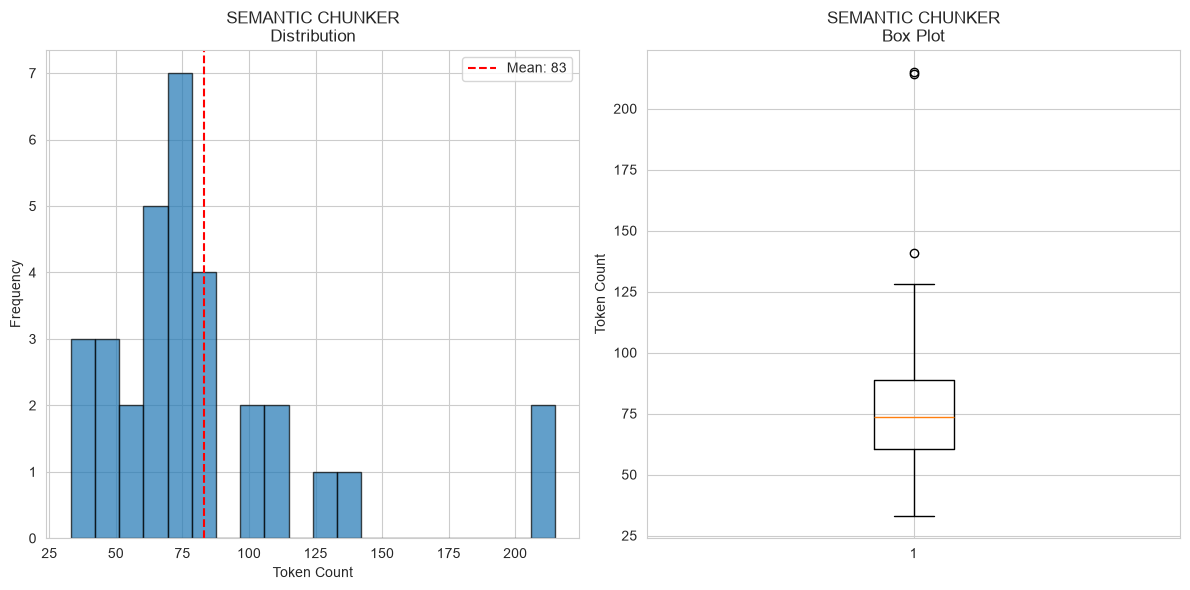


Statistics:
  Mean: 83.2
  Median: 73.5
  Std Dev: 41.6
  Min: 33
  Max: 215


In [10]:
from chonkie import SemanticChunker

semantic_chunker = SemanticChunker(
    embedding_model=oembeddings, 
    threshold=0.8,  
    chunk_size=512,
    min_sentences_per_chunk=3
)

semantic_chunks = semantic_chunker.chunk(research_paper_text)

display_chunks(semantic_chunks)
visualize_chunk_size(semantic_chunks,"SEMANTIC CHUNKER")

Loading weights: 100%|██████████| 134/134 [00:00<00:00, 27748.05it/s]
/Users/nilasark/Chunking/.venv/lib/python3.12/site-packages/chonkie/embeddings/sentence_transformer.py:62: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self._dimension = self.model.get_sentence_embedding_dimension()  # ty: ignore[deprecated]
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



 Total Lenght of chunks 6
********************************************************************************

 Chunk 1: Semantic Chunking Strategies for Retrieval-Augmented Generation Systems

Abstract

Retrieval-Augmented Generation (RAG) systems have emerged as a powerful paradigm for enhancing large language models ....
--------------------------------------------------------------------------------

 Chunk 2: This paper makes the following contributions: We present a taxonomy of nine chunking strategies spanning fixed-size, boundary-aware, semantic, and neural approaches. We conduct extensive empirical eva....
--------------------------------------------------------------------------------

 Chunk 3: Token Chunking: Splits text into fixed-size token sequences with configurable overlap. Provides predictable chunk sizes but may fragment semantic units. We evaluate with chunk sizes of 256, 512, and 1....
--------------------------------------------------------------------------------



/var/folders/j_/jb1h_wtd21zfymdrgw0tg8500000gn/T/ipykernel_77934/2283517303.py:30: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(token_counts, vert=True)


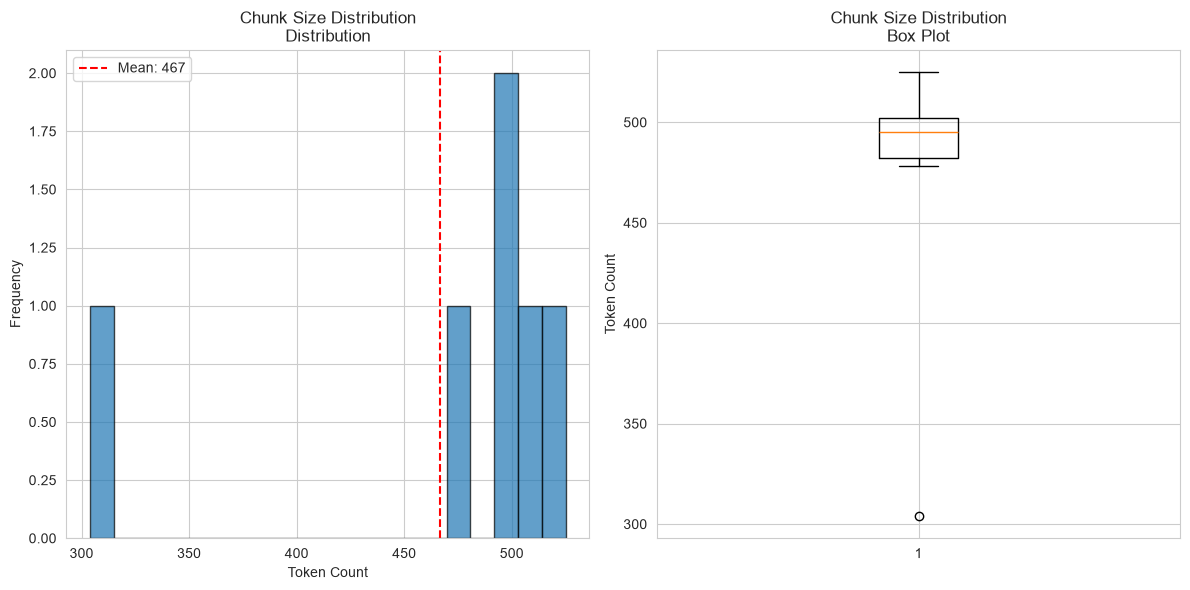


Statistics:
  Mean: 466.8
  Median: 495.0
  Std Dev: 74.2
  Min: 304
  Max: 525


In [13]:
from chonkie import LateChunker
from tokenizers import Tokenizer

tokenizer=Tokenizer.from_pretrained('gpt2')

late_chunker=LateChunker(
    embedding_model="nomic-ai/modernbert-embed-base",
    chunk_size=512
)

chunks=late_chunker.chunk(research_paper_text)
display_chunks(chunks)
visualize_chunk_size(chunks)